# Adding DMI via Lifshitz Invariants
This notebook shows how to implement **Dzyaloshinskii–Moriya Interaction (DMI)** energy terms using **Lifshitz invariants**.

## Lifshitz invariants
The Lifshitz invariants are antisymmetric combinations of magnetization components and their spatial derivatives:

$$\mathcal{L}_{ij}^{k} = m_i \partial_k m_j  -  m_j \partial_k m_i$$

where $i$, $j$, and $k$ are in $\set{x,y,z}$.

The DMI can be expressed as sums of these LI. 



## Adding LI to the energy
As an example lets take a system with exchange and a single LI of type $\mathcal{L}_{xz}^x$.

Each LI corresponds to a possible DMI contribution.
For example:

$$
w = D_{xzx} \, \mathcal{L}_{xz}^{x} = D \,( m_x \,\partial_x m_z - m_z \,\partial_x m_x ).
$$

In this system we would expect the ground state to be a cycloid propagating in the x direction.

### Setup
First we import neuralmag and create a 2D mesh.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import neuralmag as nm

nm.config.dtype = "float64"

mesh = nm.Mesh((20, 20), (1e-9, 1e-9, 1e-9))
state = nm.State(mesh)

state.m = nm.VectorFunction(state).fill((0, 0, 1))

2025-09-22 12:43:08 NeuralMag:INFO [NeuralMag] Version 0.9.3
2025-09-22 12:43:09 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2025-09-22 12:43:09 NeuralMag:INFO [NeuralMag] Set default dtype to 'float64'.
2025-09-22 12:43:09 NeuralMag:INFO [Mesh] 2D, 20 x 20 (size = 1e-09 x 1e-09 x 1e-09)
2025-09-22 12:43:09 NeuralMag:INFO [NeuralMag] Set default device to 'TFRT_CPU_0'.
2025-09-22 12:43:09 NeuralMag:INFO [State] Running on device: TFRT_CPU_0 (dtype = float64, backend = jax)


### Energy terms

We can add the other material parameters as normal.

In order to set up the LI energy terms we need to tell it what the $i$, $j$, and $k$ values are and the accociated DMI constant.
We give the indices as string in order `ijk` as argument to `nm.LIField`.
The DMI constant associated with the LI is then `Dijk`.


In [2]:
state.material.Ms = 0.86e6
state.material.alpha = 1
state.material.A = 1.3e-11
nm.ExchangeField().register(state, "exchange")


state.material.Dxzx = 15e-3
nm.LIField("xzx").register(state, "li_xzx")

nm.TotalField("exchange", "li_xzx").register(state)

2025-09-22 12:23:22 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange')
2025-09-22 12:23:22 NeuralMag:INFO [LIField] Register state methods (field: 'h_li_xzx', energy: 'E_li_xzx')
2025-09-22 12:23:22 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E')


In [3]:
# relax to energetic minimum
llg = nm.LLGSolver(state)
llg.relax(1e9)
state.write_vti(["m"], "LI/m.vti")

2025-09-22 12:23:22 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function
2025-09-22 12:23:22 NeuralMag:INFO [LLGSolverJAX] Relaxation started, initial energy E = -2.13607e-32 J
2025-09-22 12:23:23 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 4.34343e+12) 1/s
2025-09-22 12:23:23 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 1.51136e+11) 1/s
2025-09-22 12:23:23 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 2.68473e+10) 1/s
2025-09-22 12:23:23 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 5.00783e+09) 1/s
2025-09-22 12:23:23 NeuralMag:INFO [LLGSolverJAX] Relaxation finished, final energy E = -1.60663e-18 J


Plot

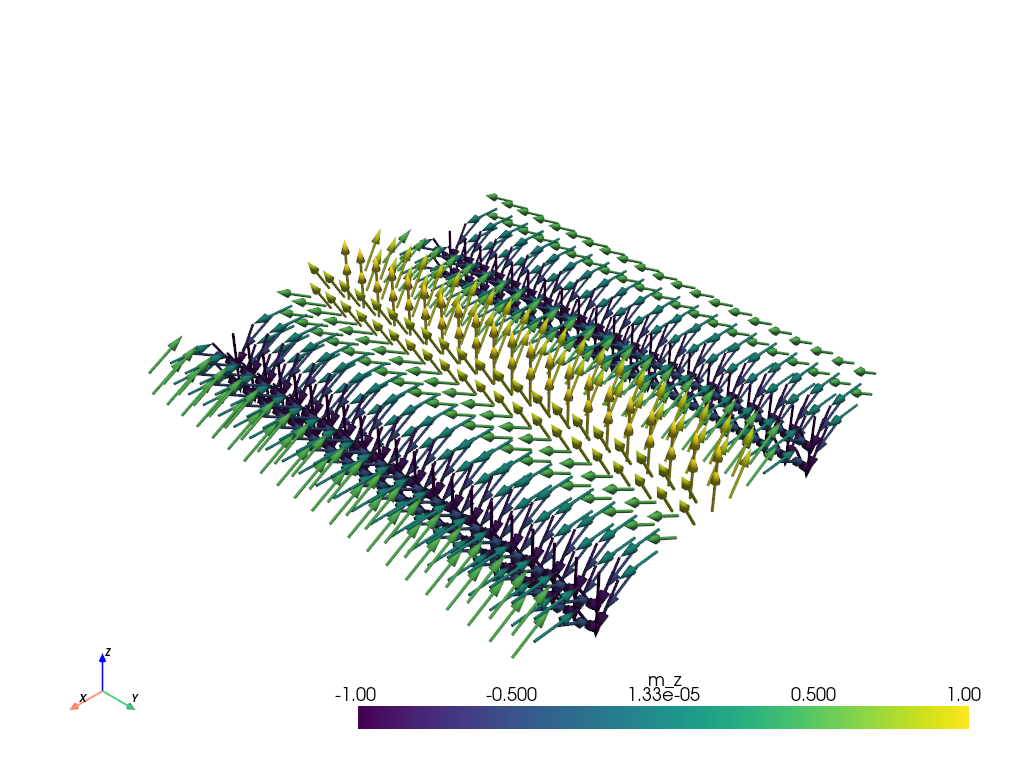

In [4]:
import pyvista as pv

pv.set_jupyter_backend("static")

grid = pv.read("LI/m.vti")
grid["m_z"] = grid["m"][:, 2]  # z component

glyphs = grid.glyph(orient="m", scale="m", factor=2e-9)

# Plot
plotter = pv.Plotter()
plotter.add_mesh(glyphs, scalars="m_z", lighting=True, smooth_shading=True)
plotter.show_axes()
plotter.show()

In [5]:
state.m = nm.VectorFunction(state).fill((0, 0, 1))

state.material.Ms = 0.86e6
state.material.alpha = 1
state.material.A = 1.3e-11
nm.ExchangeField().register(state, "exchange")


state.material.Dxzy = 15e-3
nm.LIField("xzy").register(state, "li_xzy")

nm.TotalField("exchange", "li_xzy").register(state)

2025-09-22 12:23:24 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange')
2025-09-22 12:23:24 NeuralMag:INFO [LIField] Register state methods (field: 'h_li_xzy', energy: 'E_li_xzy')
2025-09-22 12:23:24 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E')


In [6]:
# relax to energetic minimum
llg = nm.LLGSolver(state)
llg.relax(1e9)
state.write_vti(["m"], "LI/m.vti")

2025-09-22 12:23:24 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function
2025-09-22 12:23:24 NeuralMag:INFO [LLGSolverJAX] Relaxation started, initial energy E = -2.13607e-32 J
2025-09-22 12:23:25 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 4.34343e+12) 1/s
2025-09-22 12:23:25 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 1.51136e+11) 1/s
2025-09-22 12:23:25 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 2.68473e+10) 1/s
2025-09-22 12:23:25 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 5.00783e+09) 1/s
2025-09-22 12:23:25 NeuralMag:INFO [LLGSolverJAX] Relaxation finished, final energy E = -1.60663e-18 J


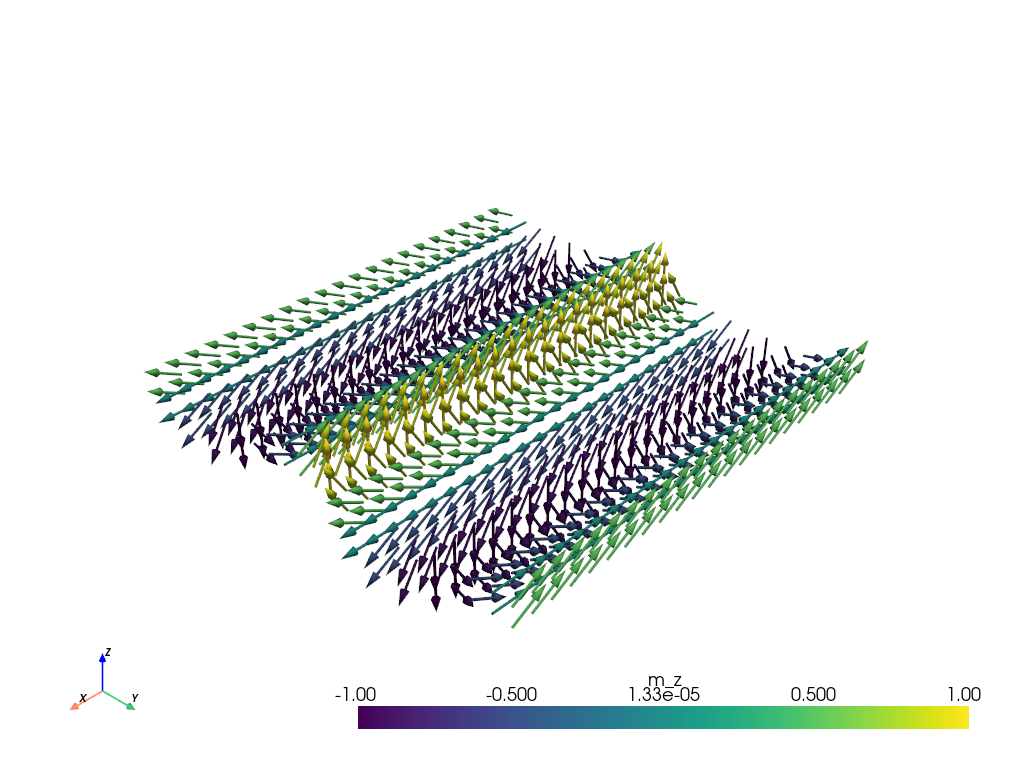

In [7]:
import pyvista as pv

pv.set_jupyter_backend("static")

grid = pv.read("LI/m.vti")
grid["m_z"] = grid["m"][:, 2]  # z component

glyphs = grid.glyph(orient="m", scale="m", factor=2e-9)

# Plot
plotter = pv.Plotter()
plotter.add_mesh(glyphs, scalars="m_z", lighting=True, smooth_shading=True)
plotter.show_axes()
plotter.show()

## Using this for particular crystalographic groups

In neuralmag we have already created energy terms for the two most common DMI classes

- Bulk (T symmetry):
  $w_D_bulk = D * m · (curl m)$
  Equivalent to a sum of Lifshitz invariants: $D*(L_yz^(x) + L_zx^(y) + L_xy^(z))$.
  

- Interfacial ($C_{\infty v}$, "Néel" type, thin film):
  w_D_int = D*[ m_z * div(m)  - (m · grad) m_z ]
  In 2D (x–y) this expands to:
  w_D_int = D*( m_z*dx m_x - m_x*dx m_z + m_z*dy m_y - m_y*dy m_z )
          = D*( L_zx^(x) + L_zy^(y) ).


\begin{tabular}{|c|c|}
      \hline
      \textbf{Point Group}      & \textbf{DMI Energy Density}
      \\
      \hline
      O, T, $D_{n}\,(n \geq 3)$ & $D(\mathcal{L}^{x}_{yz} +
        \mathcal{L}^{y}_{zx})$
      \\
      $C_{nv}\,(n \geq 3)$      & $D(\mathcal{L}^{x}_{zx} -
        \mathcal{L}^{y}_{yz})$
      \\
      $D_{2d}$                  & $D(\mathcal{L}^{x}_{yz} -
      \mathcal{L}^{y}_{zx})$                                    \\
      $S_{4}$                   & $D_{0}(\mathcal{L}^{x}_{zx} +
        \mathcal{L}^{y}_{yz}) +
        D_{1}(\mathcal{L}^{x}_{yz} - \mathcal{L}^{y}_{zx})$
      \\
      $C_{n}\,(n \geq 3)$       & $D_{0}(\mathcal{L}^{x}_{zx} -
        \mathcal{L}^{y}_{yz})
        + D_{1}(\mathcal{L}^{x}_{yz} + \mathcal{L}^{y}_{zx})$
      \\
      $D_{2}, C_{2v}$           & $D_{0}\mathcal{L}^{x}_{yz} +
        D_{1}\mathcal{L}^{y}_{zx}$
      \\
      $C_{2}$                   & $D_{0}\mathcal{L}^{x}_{zx} +
        D_{1}\mathcal{L}^{y}_{yz} +
        D_{2}\mathcal{L}^{x}_{yz} + D_{3}\mathcal{L}^{y}_{zx}$
      \\
      $C_{1h}$                  & $D_{0}\mathcal{L}^{x}_{xy} +
      D_{1}\mathcal{L}^{y}_{xy}$                                \\
      $C_{1v}$                  & $D_{0}\mathcal{L}^{x}_{zx} +
        D_{1}\mathcal{L}^{y}_{xy} +
        D_{2}\mathcal{L}^{y}_{yz}$
      \\
      $C_{1}$                   & $D_{0}\mathcal{L}^{x}_{xy} +
        D_{1}\mathcal{L}^{x}_{yz} +
        D_{2}\mathcal{L}^{x}_{zx} + D_{3}\mathcal{L}^{y}_{xy} +
        D_{4}\mathcal{L}^{y}_{yz} + D_{5}\mathcal{L}^{y}_{zx}$
      \\
      \hline
    \end{tabular}

In [8]:
mesh = nm.Mesh((10, 10, 10), (1e-9, 1e-9, 1e-9))
state = nm.State(mesh)

state.m = nm.VectorFunction(state).fill((0, 0, 1))

state.material.Ms = 0.86e6
state.material.alpha = 1
state.material.A = 1.3e-11
nm.ExchangeField().register(state, "exchange")


state.material.Db = 15e-3
nm.BulkDMIField().register(state, "bulk")

nm.TotalField("exchange", "bulk").register(state)

2025-09-22 12:23:26 NeuralMag:INFO [Mesh] 3D, 10 x 10 x 10 (size = 1e-09 x 1e-09 x 1e-09)
2025-09-22 12:23:26 NeuralMag:INFO [NeuralMag] Set default device to 'TFRT_CPU_0'.
2025-09-22 12:23:26 NeuralMag:INFO [State] Running on device: TFRT_CPU_0 (dtype = float64, backend = jax)
2025-09-22 12:23:26 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange')
2025-09-22 12:23:26 NeuralMag:INFO [BulkDMIField] Register state methods (field: 'h_bulk', energy: 'E_bulk')
2025-09-22 12:23:26 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E')


Is equivilent to 

In [9]:
mesh = nm.Mesh((10, 10, 10), (1e-9, 1e-9, 1e-9))
state = nm.State(mesh)

state.m = nm.VectorFunction(state).fill((0, 0, 1))

state.material.Ms = 0.86e6
state.material.alpha = 1
state.material.A = 1.3e-11
nm.ExchangeField().register(state, "exchange")


state.material.Dxyz = 15e-3
state.material.Dzxy = state.material.Dxyz
state.material.Dyzx = state.material.Dxyz
nm.LIField("xyz").register(state, "li_xyz")
nm.LIField("zxy").register(state, "li_zxy")
nm.LIField("yzx").register(state, "li_yzx")

nm.TotalField("exchange", "li_xyz", "li_zxy", "li_yzx").register(state)

2025-09-22 12:23:26 NeuralMag:INFO [Mesh] 3D, 10 x 10 x 10 (size = 1e-09 x 1e-09 x 1e-09)
2025-09-22 12:23:26 NeuralMag:INFO [NeuralMag] Set default device to 'TFRT_CPU_0'.
2025-09-22 12:23:26 NeuralMag:INFO [State] Running on device: TFRT_CPU_0 (dtype = float64, backend = jax)
2025-09-22 12:23:26 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange')
2025-09-22 12:23:26 NeuralMag:INFO [LIField] Register state methods (field: 'h_li_xyz', energy: 'E_li_xyz')
2025-09-22 12:23:26 NeuralMag:INFO [LIField] Register state methods (field: 'h_li_zxy', energy: 'E_li_zxy')
2025-09-22 12:23:26 NeuralMag:INFO [LIField] Register state methods (field: 'h_li_yzx', energy: 'E_li_yzx')
2025-09-22 12:23:26 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E')


However, this is really interesting because it gives us the flexibility to reduce the symmetry simply by removing the constraints that the DMi constants are the same.
This is equivilent to going from T or O crystalographic class to D2.

In [10]:
mesh = nm.Mesh((10, 10, 10), (1e-9, 1e-9, 1e-9))
state = nm.State(mesh)

state.m = nm.VectorFunction(state).fill((0, 0, 1))

state.material.Ms = 0.86e6
state.material.alpha = 1
state.material.A = 1.3e-11
nm.ExchangeField().register(state, "exchange")


state.material.Dxyz = 15e-3
state.material.Dzxy = 20e-3
state.material.Dyzx = 10e-3
nm.LIField("xyz").register(state, "li_xyz")
nm.LIField("zxy").register(state, "li_zxy")
nm.LIField("yzx").register(state, "li_yzx")

nm.TotalField("exchange", "li_xyz", "li_zxy", "li_yzx").register(state)

2025-09-22 12:23:26 NeuralMag:INFO [Mesh] 3D, 10 x 10 x 10 (size = 1e-09 x 1e-09 x 1e-09)
2025-09-22 12:23:26 NeuralMag:INFO [NeuralMag] Set default device to 'TFRT_CPU_0'.
2025-09-22 12:23:26 NeuralMag:INFO [State] Running on device: TFRT_CPU_0 (dtype = float64, backend = jax)
2025-09-22 12:23:26 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange')
2025-09-22 12:23:26 NeuralMag:INFO [LIField] Register state methods (field: 'h_li_xyz', energy: 'E_li_xyz')
2025-09-22 12:23:26 NeuralMag:INFO [LIField] Register state methods (field: 'h_li_zxy', energy: 'E_li_zxy')
2025-09-22 12:23:26 NeuralMag:INFO [LIField] Register state methods (field: 'h_li_yzx', energy: 'E_li_yzx')
2025-09-22 12:23:26 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E')


Got it — thanks for clarifying. You want something that reads like an **Ubermag tutorial**: short, direct, structured, not a long essay. Keep the original flow (intro → Lifshitz invariants → adding one LI → crystal classes). Here’s a clean Markdown/LaTeX rewrite you can paste straight into your notebook:

---

# Lifshitz invariants and DMI

## What are Lifshitz invariants?

The **Dzyaloshinskii–Moriya interaction (DMI)** can be written compactly using **Lifshitz invariants (LI)**.
A Lifshitz invariant is an antisymmetric combination of magnetisation components and their derivatives:

$$
\mathcal{L}_{ij}^{(k)} \;=\; m_i \, \partial_k m_j \;-\; m_j \, \partial_k m_i,
\qquad i,j,k \in \{x,y,z\}.
$$

They describe the “twist” of the magnetisation field $\mathbf{m}$.

---

## Adding a single Lifshitz invariant

Each LI corresponds to a possible DMI contribution.
For example:

$$
w = D \, \mathcal{L}_{zx}^{(x)} = D \,( m_z \,\partial_x m_x - m_x \,\partial_x m_z ).
$$

From this energy density, the effective field is obtained as usual:

$$
\mathbf{h} = -\frac{1}{\mu_0 M_s} \, \frac{\delta E}{\delta \mathbf{m}}.
$$

By combining different invariants, we can build the DMI appropriate for a given crystal symmetry.

---

## Common crystal classes

Different symmetries allow different sets of Lifshitz invariants:

| Symmetry                         | Allowed energy density                            | Example form                                                 |
| -------------------------------- | ------------------------------------------------- | ------------------------------------------------------------ |
| **Bulk (B20, $T$ symmetry)**     | All three terms                                   | $\;w_D = D\,\mathbf{m}\cdot(\nabla\times\mathbf{m})$         |
| **Interfacial ($C_{\infty v}$)** | Only invariants with $z$ and in-plane derivatives | $\;w_D = D(\mathcal{L}_{zx}^{(x)} + \mathcal{L}_{zy}^{(y)})$ |
| **Other classes**                | Restricted subsets depending on point group       | e.g. some tetragonal symmetries allow only one LI            |

---

## Summary

* Lifshitz invariants are the building blocks of DMI.
* Each invariant is $m_i \partial_k m_j - m_j \partial_k m_i$.
* By adding the right set of invariants, we represent the DMI for a given crystal symmetry.
* Bulk crystals → all three terms; thin films → reduced set.

---

Would you like me to also **expand the “Crystal classes” table** with a couple more point groups (tetragonal, orthorhombic) for completeness, or keep it just bulk vs. interfacial?
